# subj01 — spectral content and ~10 Hz transient artifact

This notebook checks whether the spectral peaks and the sharp ~10 Hz transient
artifact characterized in
`../investigate_spectrum_and_artifact/spectral_and_artifact.ipynb` are also
present in subject `subj01`
(`/Volumes/neuropixel_archive/tetrode_data/2026-05-27_09-07-52`).

The features looked for, reusing the reference notebook's helpers, are:

1. **Per-channel and channel-mean PSDs** (1 s Welch windows). These are plotted
   for *every* channel and as the channel mean regardless of whether any
   artifactual peaks are found.
2. **Narrowband spectral peaks** in the mean PSD, grouped into harmonic series.
   The reference session showed a common-mode ladder spaced by ~399–400 Hz
   (= `fs / 75`).
3. **Cross-channel agreement** of the peaks (common-mode signature).
4. **The sharp ~9.87 Hz negative transient** with a hardware-clocked modal
   inter-event interval of ~3038 samples.
5. **Spatial structure** of the transient across Open Ephys channel index vs.
   tetrode-grouped channel name (period-2 multiplexer signature).

This session's recordings are ~20–28 h long, so loading the whole thing would
take tens of minutes. We slice only the **first ~60 s** of each recording. The
workspace loader `open_tetrode_dataarray` materializes the full `time`
coordinate eagerly, which is prohibitive for a 3-billion-sample recording, so we
use a thin first-N-seconds loader that slices the memmap *before* building the
DataArray. It returns the same `2d_flat_index` layout (plus an `oe_index`
coord) so the reference helpers apply unchanged.

In [1]:
%matplotlib inline
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from open_ephys import analysis as oea
from scipy import signal as sp_signal

from tetrode_analyses import load_channel_map, print_session_tree

In [2]:
ACQ_DIR = Path("/Volumes/neuropixel_archive/tetrode_data/2026-05-27_09-07-52")
STREAM_INDEX = 0  # acquisition_board
SECONDS = 60.0    # only the first ~60 s of each (very long) recording

print_session_tree(ACQ_DIR)

Session: /Volumes/neuropixel_archive/tetrode_data/2026-05-27_09-07-52
  Record Node 121 (binary)  [record_node_index=0]
    experiment1  [experiment_index=0]
      recording1  [recording_index=0]
        Stream 0: acquisition_board  — 64 ch, 3,025,748,403 samples @ 30000.0 Hz, 100858.280 s
        Stream 1: memory_usage  — 1 ch, 10,085,828 samples @ 100.0 Hz, 100858.280 s
    experiment2  [experiment_index=1]
      recording1  [recording_index=0]


        Stream 0: acquisition_board  — 64 ch, 2,189,284,649 samples @ 30000.0 Hz, 72976.155 s
        Stream 1: memory_usage  — 1 ch, 7,297,615 samples @ 100.0 Hz, 72976.150 s


## Helpers

`channel_psds`, `detect_transients`, `find_psd_peaks`, and `harmonic_groups` are
copied verbatim from the reference notebook so the comparison is apples-to-apples.
`load_first_seconds` is the only new piece: it slices the memmap to the first
`SECONDS` seconds and scales int16 → microvolts, avoiding the full-length
`time` coordinate that makes the standard loader intractable here.

In [3]:
def load_first_seconds(
    acq_dir,
    *,
    record_node_index: int = 0,
    experiment_index: int = 0,
    recording_index: int = 0,
    stream_index: int = 0,
    selected_tetrodes=None,
    seconds: float = 60.0,
    dtype: str = "float32",
) -> xr.DataArray:
    """First ``seconds`` of one continuous stream as a ``2d_flat_index`` DataArray.

    Mirrors ``open_tetrode_dataarray(layout="2d_flat_index")`` but slices the
    int16 memmap to the first ``seconds`` seconds *before* constructing the
    DataArray, so the full-length ``time`` coordinate is never materialized.
    Adds an ``oe_index`` coord (0-based Open Ephys hardware channel index).
    """
    acq_dir = Path(acq_dir)
    session = oea.Session(str(acq_dir))
    node = session.recordnodes[record_node_index]
    # Channel map is an experiment-level property; block_index selects the right
    # settings*.xml (settings.xml for experiment1, settings_N.xml otherwise).
    chmap = load_channel_map(acq_dir, block_index=experiment_index)
    tt2ch_ixs = chmap["tt2ch_ixs"]

    rec = next(
        r
        for r in node.recordings
        if r.experiment_index == experiment_index
        and r.recording_index == recording_index
    )
    cont = rec.continuous[stream_index]
    fs = float(cont.metadata.sample_rate)

    if selected_tetrodes is None:
        selected_tetrodes = sorted(tt2ch_ixs)

    all_names = cont.metadata.channel_names
    bit_volts_all = cont.metadata.bit_volts
    oe_ixs, ch_names, tt_labels = [], [], []
    for tt in selected_tetrodes:
        for ch in tt2ch_ixs[tt]:
            oe_ixs.append(ch)
            ch_names.append(all_names[ch])
            tt_labels.append(f"TT{tt}")

    n = min(int(round(seconds * fs)), cont.samples.shape[0])
    raw = np.asarray(cont.samples[:n])[:, oe_ixs]  # (n, n_ch) int16
    bit_volts = np.array([bit_volts_all[ch] for ch in oe_ixs], dtype=dtype)
    samples = raw.astype(dtype) * bit_volts  # microvolts
    ts = np.asarray(cont.timestamps[:n])

    return xr.DataArray(
        samples,
        dims=("time", "channel"),
        coords={
            "time": ("time", ts),
            "channel": ("channel", ch_names),
            "tetrode": ("channel", tt_labels),
            "oe_index": ("channel", np.array(oe_ixs)),
        },
        attrs={"fs": fs, "units": "microvolts"},
    )


def channel_psds(samples: np.ndarray, fs: float, nperseg: int | None = None):
    """Welch PSD per channel. ``samples`` is ``(n_samples, n_channels)``."""
    if nperseg is None:
        nperseg = int(round(fs))  # 1 s windows
    freqs, psds = sp_signal.welch(samples, fs=fs, nperseg=nperseg, axis=0)
    return freqs, psds


def detect_transients(
    x: np.ndarray,
    fs: float,
    hp_cutoff: float = 300.0,
    threshold_mad: float = 6.0,
    min_distance_s: float = 0.05,
):
    """High-pass + robust threshold detector for sharp transients."""
    sos = sp_signal.butter(4, hp_cutoff, btype="high", fs=fs, output="sos")
    hp = sp_signal.sosfiltfilt(sos, x)
    abs_hp = np.abs(hp)
    med = np.median(abs_hp)
    mad = np.median(np.abs(abs_hp - med))
    threshold = med + threshold_mad * 1.4826 * mad
    distance = max(1, int(round(min_distance_s * fs)))
    peaks, _ = sp_signal.find_peaks(abs_hp, height=threshold, distance=distance)
    return peaks, hp, threshold


def find_psd_peaks(
    freqs: np.ndarray,
    psd: np.ndarray,
    fmin: float = 1.0,
    fmax: float | None = None,
    prominence_db: float = 6.0,
    min_distance_hz: float = 0.5,
):
    """Find peaks in dB PSD between ``fmin`` and ``fmax``."""
    if fmax is None:
        fmax = freqs[-1]
    mask = (freqs >= fmin) & (freqs <= fmax)
    f = freqs[mask]
    p_db = 10 * np.log10(psd[mask] + 1e-30)
    df = f[1] - f[0]
    distance = max(1, int(round(min_distance_hz / df)))
    idx, props = sp_signal.find_peaks(p_db, prominence=prominence_db, distance=distance)
    return f[idx], p_db[idx], props["prominences"]


def harmonic_groups(peak_freqs: np.ndarray, tolerance: float = 0.05):
    """Group peaks by best-fitting fundamental."""
    peak_freqs = np.sort(np.asarray(peak_freqs, dtype=float))
    groups: dict[float, list[tuple[int, float]]] = {}
    for f in peak_freqs:
        assigned = False
        for f0 in list(groups):
            order = int(round(f / f0))
            if order >= 1 and abs(f - order * f0) / (order * f0) <= tolerance:
                groups[f0].append((order, f))
                assigned = True
                break
        if not assigned:
            groups[f] = [(1, f)]
    return groups

## 1. Experiment 0, first 60 s: per-channel PSDs (1 s windows)

Load **all 64 channels** (all 16 tetrodes) and run Welch PSD with
`nperseg = fs` (1 s windows, default 50% overlap). The per-channel PSDs and the
channel-mean PSD are plotted whether or not any artifactual peaks are present.

In [4]:
da0 = load_first_seconds(
    ACQ_DIR,
    experiment_index=0,
    recording_index=0,
    stream_index=STREAM_INDEX,
    selected_tetrodes=None,
    seconds=SECONDS,
)
fs = float(da0.attrs["fs"])
print(da0)

<xarray.DataArray (time: 1800000, channel: 64)> Size: 461MB
array([[102.375    , 128.11499  , 108.615    , ..., 112.905    ,
        101.98499  , 123.045    ],
       [119.534996 , 122.06999  , 108.81     , ..., 108.225    ,
         91.649994 , 110.564995 ],
       [113.295    , 119.34     ,  99.255    , ..., 113.295    ,
        100.424995 , 104.715    ],
       ...,
       [ -7.6049995, -14.235    ,  -5.265    , ..., -44.07     ,
        -43.68     , -39.39     ],
       [ -9.945    , -23.595    ,  -1.365    , ..., -33.735    ,
        -37.44     , -22.035    ],
       [-13.844999 , -31.199999 ,  -8.19     , ..., -22.814999 ,
        -44.655    , -31.199999 ]], shape=(1800000, 64), dtype=float32)
Coordinates:
  * time      (time) float64 14MB 2.582 2.582 2.582 2.582 ... 62.58 62.58 62.58
  * channel   (channel) <U4 1kB 'CH40' 'CH38' 'CH36' ... 'CH28' 'CH30' 'CH32'
    tetrode   (channel) <U4 1kB 'TT1' 'TT1' 'TT1' 'TT1' ... 'TT16' 'TT16' 'TT16'
    oe_index  (channel) int64 512B 39 3

In [5]:
freqs0, psds0 = channel_psds(da0.values, fs=fs)
mean_psd0 = psds0.mean(axis=1)
print(f"loaded {da0.sizes['time'] / fs:.2f} s, {da0.sizes['channel']} channels")
print(f"freqs: {freqs0[0]:.3f} .. {freqs0[-1]:.1f} Hz, df = {freqs0[1] - freqs0[0]:.3f} Hz")
print(f"psds shape: {psds0.shape}")

loaded 60.00 s, 64 channels
freqs: 0.000 .. 15000.0 Hz, df = 1.000 Hz
psds shape: (15001, 64)


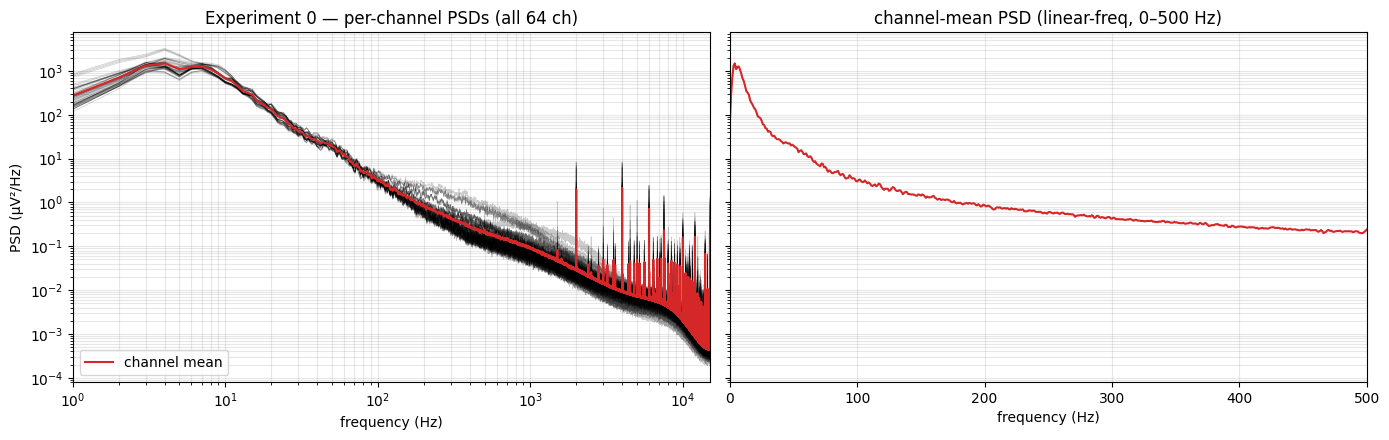

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for i in range(psds0.shape[1]):
    axes[0].loglog(freqs0, psds0[:, i], color="k", alpha=0.2, lw=0.5)
axes[0].loglog(freqs0, mean_psd0, color="C3", lw=1.5, label="channel mean")
axes[0].set(xlabel="frequency (Hz)", ylabel="PSD (\u00b5V\u00b2/Hz)",
            title=f"Experiment 0 \u2014 per-channel PSDs (all {psds0.shape[1]} ch)")
axes[0].set_xlim(freqs0[1], freqs0[-1])
axes[0].legend(loc="lower left")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(freqs0, mean_psd0, color="C3")
axes[1].set(xlabel="frequency (Hz)", title="channel-mean PSD (linear-freq, 0\u2013500 Hz)")
axes[1].set_xlim(0, 500)
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## 2. PSD peaks and harmonics

Pull prominent peaks (≥ 6 dB prominence) out of the mean PSD and group them by
best-fitting fundamental. In the reference session the true spacing was
~399–400 Hz (`fs / 75`).

In [7]:
peak_f0, peak_db0, peak_prom0 = find_psd_peaks(freqs0, mean_psd0, fmin=1.0)
groups0 = harmonic_groups(peak_f0)

print(f"Detected {len(peak_f0)} prominent peaks in mean PSD (\u2265 6 dB prominence)")
if len(peak_f0):
    print("\nHarmonic groupings (fundamental \u2192 [(order, freq Hz)...]):")
    for f0_ in sorted(groups0):
        series = groups0[f0_]
        if len(series) == 1:
            print(f"  isolated  {f0_:8.3f} Hz")
        else:
            labels = ", ".join(f"{o}x={fi:.2f}" for o, fi in series)
            print(f"  f0 = {f0_:7.3f} Hz: {labels}")

# Spacing between consecutive low-order peaks (reference ladder was ~399 Hz apart).
if len(peak_f0) >= 2:
    low = np.sort(peak_f0[peak_f0 < 8000])
    if low.size >= 2:
        diffs = np.diff(low)
        print(f"\nMedian spacing of consecutive peaks < 8 kHz: {np.median(diffs):.1f} Hz "
              f"(reference ladder \u2248 399\u2013400 Hz = fs/75 = {fs/75:.1f} Hz)")

Detected 48 prominent peaks in mean PSD (≥ 6 dB prominence)

Harmonic groupings (fundamental → [(order, freq Hz)...]):
  f0 =   4.000 Hz: 1x=4.00, 499x=1995.00, 875x=3500.00, 998x=3990.00, 1097x=4389.00, 1125x=4500.00, 1197x=4788.00, 1250x=5000.00, 1297x=5187.00, 1397x=5587.00, 1496x=5986.00, 1500x=6000.00, 1596x=6385.00, 1696x=6784.00, 1796x=7183.00, 1875x=7500.00, 1896x=7582.00, 1995x=7981.00, 2000x=8000.00, 2095x=8380.00, 2195x=8779.00, 2294x=9178.00, 2375x=9500.00, 2394x=9577.00, 2494x=9976.00, 2500x=10000.00, 2512x=10048.00, 2594x=10375.00, 2625x=10500.00, 2694x=10774.00, 2750x=11000.00, 2793x=11173.00, 2875x=11500.00, 2893x=11572.00, 2993x=11971.00, 3000x=12000.00, 3092x=12370.00, 3125x=12500.00, 3192x=12769.00, 3250x=13000.00, 3292x=13168.00, 3392x=13567.00, 3492x=13966.00, 3500x=14000.00, 3510x=14039.00, 3591x=14365.00, 3625x=14500.00, 3691x=14764.00

Median spacing of consecutive peaks < 8 kHz: 399.0 Hz (reference ladder ≈ 399–400 Hz = fs/75 = 400.0 Hz)


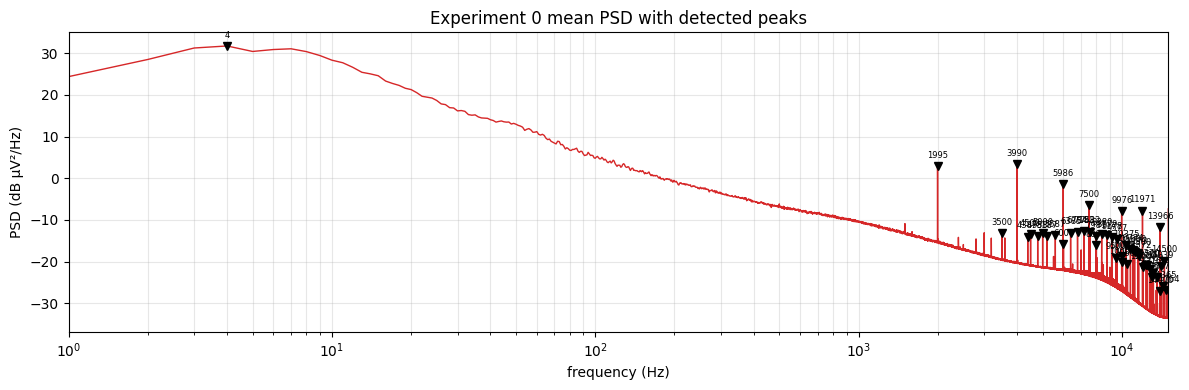

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
p_db_full0 = 10 * np.log10(mean_psd0 + 1e-30)
ax.plot(freqs0, p_db_full0, color="C3", lw=1)
if len(peak_f0):
    ax.plot(peak_f0, peak_db0, "v", color="k", ms=6)
    for f, db in zip(peak_f0, peak_db0):
        ax.annotate(f"{f:.0f}", (f, db), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=6)
ax.set(xlabel="frequency (Hz)", ylabel="PSD (dB \u00b5V\u00b2/Hz)",
       title="Experiment 0 mean PSD with detected peaks")
ax.set_xscale("log")
ax.set_xlim(freqs0[1], freqs0[-1])
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 2b. Are the spectral peaks the same on every channel?

Run the peak detector on each channel's PSD individually and count how many
channels each candidate peak appears on (±1 Hz). Peaks present on (nearly) all
channels are common-mode — the signature of a clocked acquisition source.

In [9]:
per_channel_peaks = []
for c in range(psds0.shape[1]):
    pf, _, _ = find_psd_peaks(freqs0, psds0[:, c], fmin=1.0, prominence_db=6.0)
    per_channel_peaks.append(np.round(pf).astype(int))

pool = Counter()
for pf in per_channel_peaks:
    pool.update(pf.tolist())

n_ch = psds0.shape[1]
candidates = sorted(f for f, c in pool.items() if c >= max(2, n_ch // 4))
present = np.zeros((n_ch, len(candidates)), dtype=bool)
for c, pf in enumerate(per_channel_peaks):
    s = set(pf.tolist())
    for j, f in enumerate(candidates):
        present[c, j] = bool(s & {f - 1, f, f + 1})

per_chan_count = present.sum(axis=0)
universal = [candidates[j] for j in range(len(candidates)) if per_chan_count[j] == n_ch]
print(f"{len(universal)} peaks appear on ALL {n_ch} channels:")
for f in universal:
    print(f"  {f} Hz")

high_agreement = [(candidates[j], per_chan_count[j]) for j in range(len(candidates))
                  if per_chan_count[j] >= n_ch - 2 and candidates[j] not in universal]
print(f"\nPeaks on \u2265 {n_ch - 2}/{n_ch} channels (near-universal):")
for f, n in sorted(high_agreement):
    print(f"  {f} Hz: {n}/{n_ch}")

26 peaks appear on ALL 64 channels:
  1995 Hz
  3990 Hz
  5587 Hz
  5986 Hz
  6385 Hz
  6784 Hz
  7183 Hz
  7582 Hz
  7981 Hz
  8380 Hz
  8779 Hz
  9178 Hz
  9577 Hz
  9976 Hz
  10048 Hz
  10375 Hz
  10774 Hz
  11173 Hz
  11572 Hz
  11971 Hz
  12370 Hz
  12769 Hz
  13168 Hz
  13567 Hz
  13966 Hz
  14039 Hz

Peaks on ≥ 62/64 channels (near-universal):
  14365 Hz: 62/64


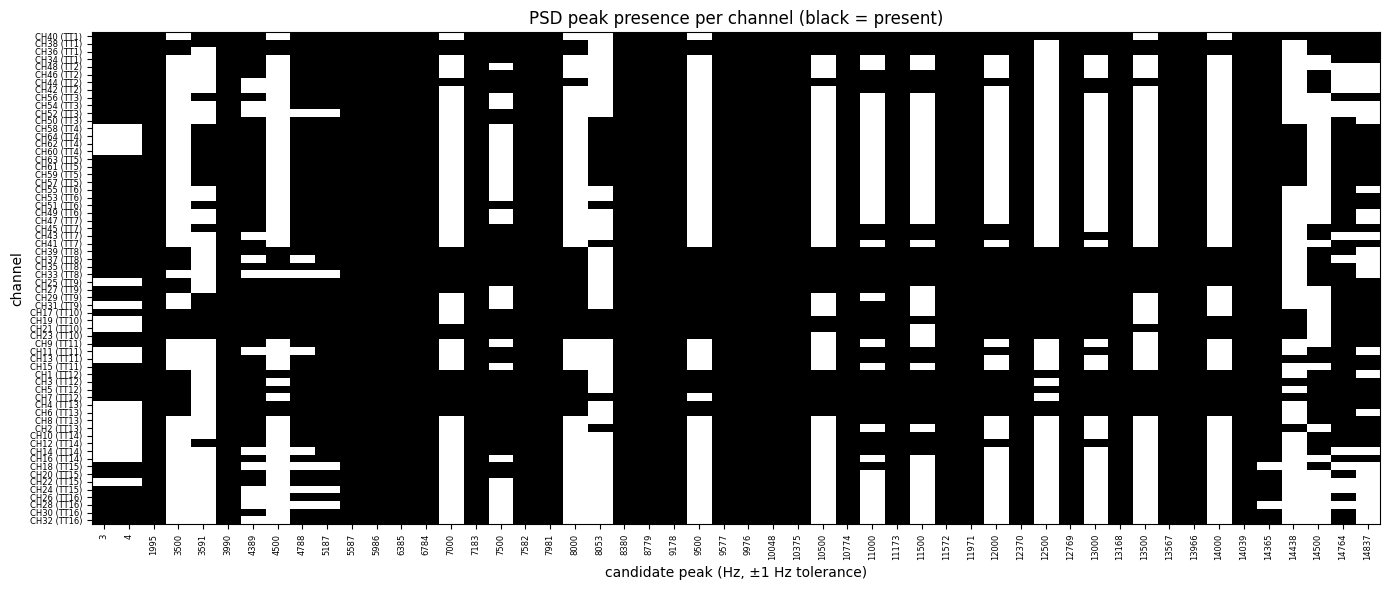

In [10]:
if len(candidates):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(present.astype(int), aspect="auto", cmap="Greys", interpolation="nearest",
              extent=[-0.5, len(candidates) - 0.5, n_ch - 0.5, -0.5])
    ax.set_xticks(range(len(candidates)))
    ax.set_xticklabels([str(f) for f in candidates], rotation=90, fontsize=6)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels([f"{c} ({t})" for c, t in
                         zip(da0["channel"].values, da0["tetrode"].values)], fontsize=6)
    ax.set(xlabel="candidate peak (Hz, \u00b11 Hz tolerance)", ylabel="channel",
           title="PSD peak presence per channel (black = present)")
    fig.tight_layout()
    plt.show()
else:
    print("No candidate peaks shared across channels.")

## 3. Detect the ~10 Hz sharp transient

High-pass at 300 Hz and threshold on a robust (MAD) baseline. The reference rate
was ~9.88 Hz.

In [11]:
ch0 = da0.values[:, 0]
peaks0, hp0, thr0 = detect_transients(ch0, fs=fs)
n_events = len(peaks0)
duration = da0.sizes["time"] / fs
print(f"{n_events} events on channel 0 ({da0['channel'].values[0]}) over {duration:.2f} s "
      f"=> {n_events / duration:.3f} Hz")

556 events on channel 0 (CH40) over 60.00 s => 9.267 Hz


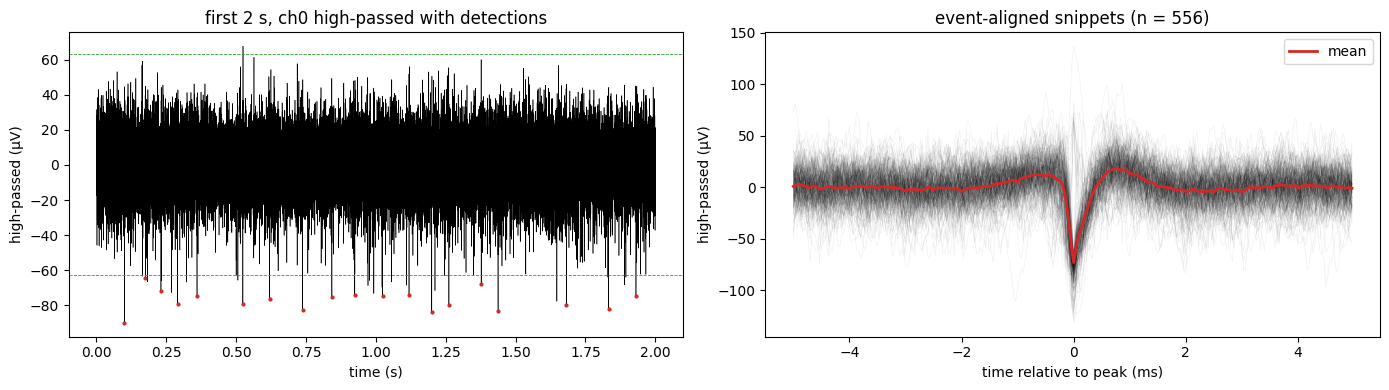

In [12]:
win = int(0.005 * fs)  # \u00b15 ms around peak
snippets = np.stack([hp0[p - win:p + win] for p in peaks0
                     if win <= p < len(hp0) - win]) if n_events else np.empty((0, 2 * win))
t_snip = np.arange(-win, win) / fs * 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t = np.arange(len(hp0)) / fs
show = slice(0, int(2 * fs))  # first 2 s
axes[0].plot(t[show], hp0[show], lw=0.4, color="k")
if n_events:
    sel = peaks0[peaks0 < show.stop]
    axes[0].plot(sel / fs, hp0[sel], ".", color="C3", ms=4)
axes[0].axhline(thr0, color="C2", lw=0.6, ls="--")
axes[0].axhline(-thr0, color="C2", lw=0.6, ls="--")
axes[0].set(xlabel="time (s)", ylabel="high-passed (\u00b5V)",
            title="first 2 s, ch0 high-passed with detections")

if len(snippets):
    for s in snippets[: min(200, len(snippets))]:
        axes[1].plot(t_snip, s, color="k", alpha=0.06, lw=0.5)
    axes[1].plot(t_snip, snippets.mean(axis=0), color="C3", lw=2, label="mean")
    axes[1].legend()
axes[1].set(xlabel="time relative to peak (ms)", ylabel="high-passed (\u00b5V)",
            title=f"event-aligned snippets (n = {len(snippets)})")
fig.tight_layout()
plt.show()

## 4. Sample-precise periodicity?

If the artifact is hardware-clocked, one modal inter-event interval should
dominate and the spread should be 0–1 samples. The reference modal interval was
3038 samples (9.8749 Hz).

In [13]:
if peaks0.size >= 2:
    diffs0 = np.diff(peaks0)
    vals, counts = np.unique(diffs0, return_counts=True)
    order = np.argsort(counts)[::-1]
    modal_interval = int(vals[order[0]])
    modal_freq = fs / modal_interval
    print(f"inter-event intervals: min={diffs0.min()} max={diffs0.max()} "
          f"mean={diffs0.mean():.2f} median={int(np.median(diffs0))}")
    print(f"modal interval = {modal_interval} samples "
          f"({modal_interval / fs * 1e3:.4f} ms, {modal_freq:.4f} Hz)")
    print("top intervals (samples, count):")
    for v, c in zip(vals[order[:10]], counts[order[:10]]):
        print(f"  {int(v):6d}  {int(c):5d}  ({c / diffs0.size * 100:.1f}%)")
    exact = int(np.sum(diffs0 == modal_interval))
    within1 = int(np.sum(np.abs(diffs0 - modal_interval) <= 1))
    print(f"\n{exact}/{diffs0.size} ({exact / diffs0.size * 100:.1f}%) intervals "
          f"exactly equal modal value")
    print(f"{within1}/{diffs0.size} ({within1 / diffs0.size * 100:.1f}%) within \u00b11 sample")
else:
    diffs0 = np.array([])
    modal_interval = 0
    print("Too few events to characterize periodicity.")

inter-event intervals: min=1501 max=11688 mean=3232.58 median=2776
modal interval = 2953 samples (98.4333 ms, 10.1592 Hz)
top intervals (samples, count):
    2953      2  (0.4%)
    4062      2  (0.4%)
    1628      2  (0.4%)
    4078      2  (0.4%)
    2175      2  (0.4%)
    1640      2  (0.4%)
    2527      2  (0.4%)
    1655      2  (0.4%)
    2524      2  (0.4%)
    1661      2  (0.4%)

2/555 (0.4%) intervals exactly equal modal value
2/555 (0.4%) within ±1 sample


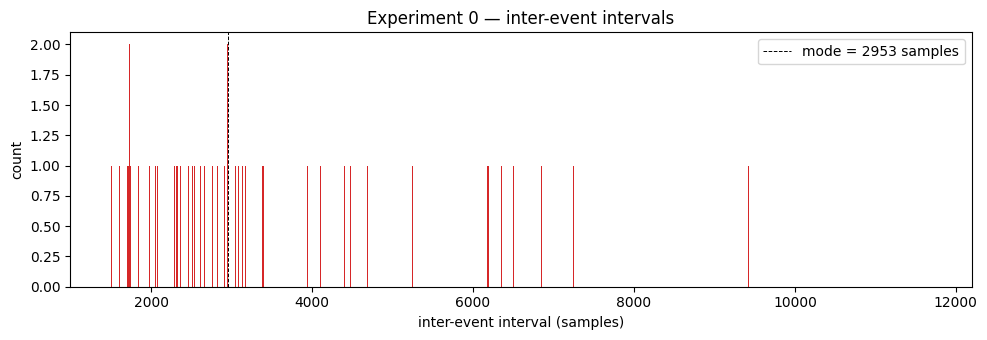

In [14]:
if diffs0.size:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    bins = np.arange(diffs0.min() - 0.5, diffs0.max() + 1.5)
    ax.hist(diffs0, bins=bins, color="C3")
    ax.axvline(modal_interval, color="k", lw=0.7, ls="--",
               label=f"mode = {modal_interval} samples")
    ax.set(xlabel="inter-event interval (samples)", ylabel="count",
           title="Experiment 0 \u2014 inter-event intervals")
    ax.legend()
    fig.tight_layout()
    plt.show()

## 4b. Sign-aware artifact detection

`detect_transients` thresholds on `|hp|`, mixing positive- and negative-going
lobes of a possibly biphasic transient. Re-run separately for positive and
negative excursions. In the reference the artifact was predominantly *negative*,
and sign-locking tightened the modal-interval fraction.

In [15]:
abs_hp = np.abs(hp0)
med = np.median(abs_hp)
mad = np.median(np.abs(abs_hp - med))
thr_signed = med + 6 * 1.4826 * mad
distance = max(1, int(round(0.05 * fs)))

pos_peaks, _ = sp_signal.find_peaks(hp0, height=thr_signed, distance=distance)
neg_peaks, _ = sp_signal.find_peaks(-hp0, height=thr_signed, distance=distance)


def interval_summary(peaks, label):
    if peaks.size < 2:
        print(f"{label}: {peaks.size} events, nothing to summarize")
        return
    diffs = np.diff(peaks)
    vals, counts = np.unique(diffs, return_counts=True)
    order = np.argsort(counts)[::-1]
    mode = int(vals[order[0]])
    exact = int(np.sum(diffs == mode))
    within1 = int(np.sum(np.abs(diffs - mode) <= 1))
    print(f"{label}: n={peaks.size}, modal interval = {mode} samp "
          f"({mode / fs * 1e3:.4f} ms, {fs / mode:.4f} Hz)")
    print(f"  %exact = {exact / diffs.size * 100:.1f}, "
          f"within \u00b11 samp = {within1 / diffs.size * 100:.1f}")
    top = list(zip(vals[order[:5]].astype(int), counts[order[:5]].astype(int)))
    print(f"  top intervals: {top}")


print("Combined |hp| detector (original):")
interval_summary(peaks0, "  |hp|")
print("\nSign-split detectors:")
interval_summary(pos_peaks, "  positive")
interval_summary(neg_peaks, "  negative")

Combined |hp| detector (original):
  |hp|: n=556, modal interval = 2953 samp (98.4333 ms, 10.1592 Hz)
  %exact = 0.4, within ±1 samp = 0.4
  top intervals: [(np.int64(2953), np.int64(2)), (np.int64(4062), np.int64(2)), (np.int64(1628), np.int64(2)), (np.int64(4078), np.int64(2)), (np.int64(2175), np.int64(2))]

Sign-split detectors:
  positive: n=134, modal interval = 3039 samp (101.3000 ms, 9.8717 Hz)
  %exact = 2.3, within ±1 samp = 3.8
  top intervals: [(np.int64(3039), np.int64(3)), (np.int64(3038), np.int64(2)), (np.int64(49889), np.int64(1)), (np.int64(55143), np.int64(1)), (np.int64(48474), np.int64(1))]
  negative: n=540, modal interval = 2224 samp (74.1333 ms, 13.4892 Hz)
  %exact = 0.4, within ±1 samp = 0.4
  top intervals: [(np.int64(2224), np.int64(2)), (np.int64(1880), np.int64(2)), (np.int64(2647), np.int64(2)), (np.int64(1908), np.int64(2)), (np.int64(2351), np.int64(2))]


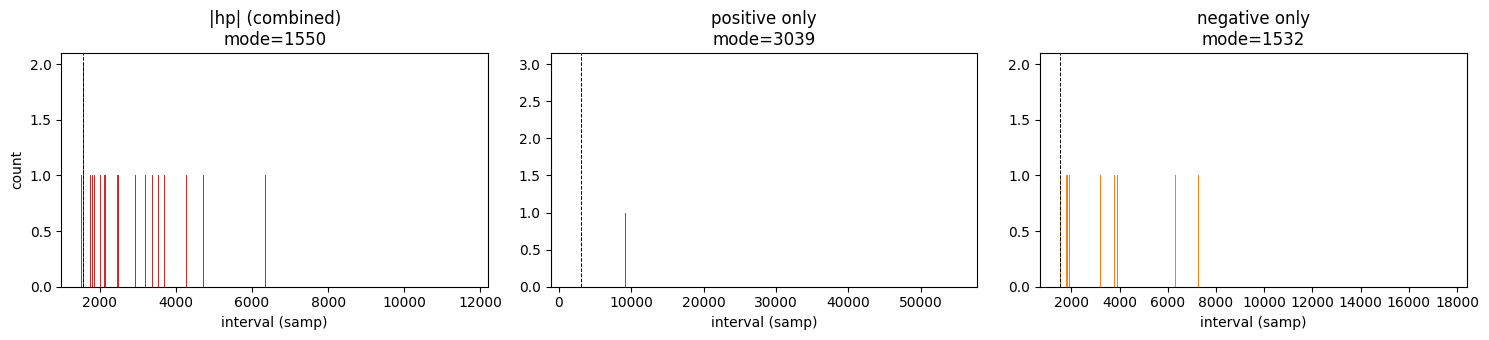

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharex=False)
for ax, peaks, name, color in zip(
    axes,
    (peaks0, pos_peaks, neg_peaks),
    ("|hp| (combined)", "positive only", "negative only"),
    ("C3", "C0", "C1"),
):
    if peaks.size < 2:
        ax.set_title(f"{name}: <2 events")
        continue
    diffs = np.diff(peaks)
    bins = np.arange(diffs.min() - 0.5, diffs.max() + 1.5)
    ax.hist(diffs, bins=bins, color=color)
    mode = int(np.bincount(diffs).argmax())
    ax.axvline(mode, color="k", lw=0.7, ls="--")
    ax.set(xlabel="interval (samp)", title=f"{name}\nmode={mode}")
axes[0].set_ylabel("count")
fig.tight_layout()
plt.show()

## 5. Spatial pattern across Open Ephys channels

Build the event-triggered average (ETA) for every channel, then order rows two
ways: by raw OE hardware index and by tetrode-grouped channel name. A period-2
alternation that exists only in OE-index order is the multiplexer / ADC-bound
signature seen in the reference session.

In [17]:
sos_hp = sp_signal.butter(4, 300, btype="high", fs=fs, output="sos")
hp_all = sp_signal.sosfiltfilt(sos_hp, da0.values, axis=0)

oe_index = da0["oe_index"].values
order_by_oe = np.argsort(oe_index)

valid = peaks0[(peaks0 >= win) & (peaks0 < hp_all.shape[0] - win)]
snip_idx = valid[:, None] + np.arange(-win, win)[None, :]
eta = hp_all[snip_idx, :].mean(axis=0)  # (2*win, n_ch)
eta_by_oe = eta[:, order_by_oe]
oe_sorted = oe_index[order_by_oe]
amp_at_zero = eta[win, :]
print(f"ETA from {valid.size} events, {eta.shape[1]} channels; "
      f"OE index range {oe_index.min()}\u2013{oe_index.max()}")

ETA from 556 events, 64 channels; OE index range 0–63


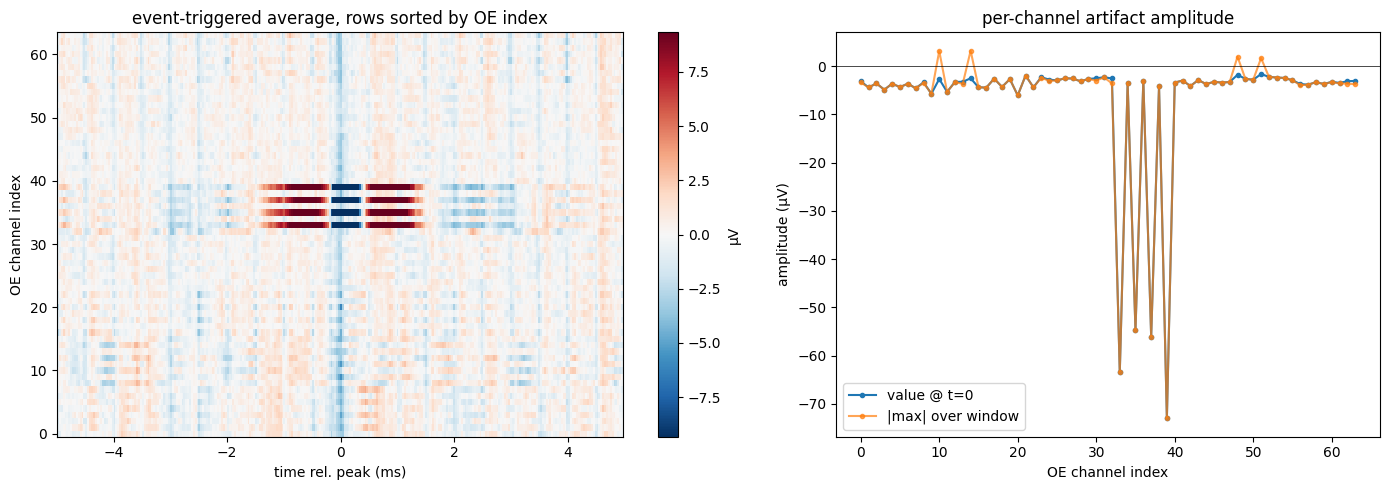

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [1.3, 1]})
vmax = np.percentile(np.abs(eta_by_oe), 99)
im = axes[0].imshow(eta_by_oe.T, aspect="auto", origin="lower",
                    extent=[t_snip[0], t_snip[-1], oe_sorted[0] - 0.5, oe_sorted[-1] + 0.5],
                    vmin=-vmax, vmax=vmax, cmap="RdBu_r", interpolation="nearest")
axes[0].set(xlabel="time rel. peak (ms)", ylabel="OE channel index",
            title="event-triggered average, rows sorted by OE index")
fig.colorbar(im, ax=axes[0], label="\u00b5V")

amp_oe = amp_at_zero[order_by_oe]
peak_amp_oe = eta_by_oe[np.abs(eta_by_oe).argmax(axis=0), np.arange(eta_by_oe.shape[1])]
axes[1].plot(oe_sorted, amp_oe, ".-", label="value @ t=0")
axes[1].plot(oe_sorted, peak_amp_oe, ".-", label="|max| over window", alpha=0.7)
axes[1].set(xlabel="OE channel index", ylabel="amplitude (\u00b5V)",
            title="per-channel artifact amplitude")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].legend()
fig.tight_layout()
plt.show()

In [19]:
# Spatial-frequency content of artifact amplitude vs OE index.
amp = amp_oe - amp_oe.mean()
n = amp.size
P = np.abs(np.fft.rfft(amp)) ** 2
k_axis = np.arange(P.size)
period = np.where(k_axis > 0, n / np.maximum(k_axis, 1), np.inf)
top_oe = np.argsort(P[1:])[::-1][:5] + 1
print("Top spatial-frequency components of artifact amplitude vs OE index:")
for k in top_oe:
    print(f"  k = {int(k):2d} cycles \u2192 period \u2248 {period[k]:.2f} channels, power = {P[k]:.3g}")

Top spatial-frequency components of artifact amplitude vs OE index:
  k = 32 cycles → period ≈ 2.00 channels, power = 5.47e+04
  k = 30 cycles → period ≈ 2.13 channels, power = 4.96e+04
  k =  2 cycles → period ≈ 32.00 channels, power = 4.9e+04
  k = 31 cycles → period ≈ 2.06 channels, power = 4.69e+04
  k =  1 cycles → period ≈ 64.00 channels, power = 4.61e+04


## 5b. Spatial pattern by tetrode-grouped channel name

The channel axis as loaded is already tetrode-grouped (positions 1–4 = TT1,
5–8 = TT2, …). If the period-2 structure is multiplexer-bound it should wash out
here (no 4-wide tetrode blocks).

In [20]:
name_pos = np.arange(1, da0.sizes["channel"] + 1)  # tetrode-grouped position
eta_by_name = eta  # already in tetrode-grouped order
amp_name = eta[win, :]
amp_n = amp_name - amp_name.mean()
P_name = np.abs(np.fft.rfft(amp_n)) ** 2
top_name = np.argsort(P_name[1:])[::-1][:5] + 1
print("Top spatial-frequency components of artifact amp vs channel_name (tetrode order):")
for k in top_name:
    print(f"  k = {int(k):2d} cycles \u2192 period \u2248 {amp_n.size / k:.2f} channels, "
          f"power = {P_name[k]:.3g}")

Top spatial-frequency components of artifact amp vs channel_name (tetrode order):
  k =  1 cycles → period ≈ 64.00 channels, power = 5.05e+04
  k =  4 cycles → period ≈ 16.00 channels, power = 4.85e+04
  k =  2 cycles → period ≈ 32.00 channels, power = 4.82e+04
  k =  3 cycles → period ≈ 21.33 channels, power = 4.72e+04
  k =  5 cycles → period ≈ 12.80 channels, power = 4.66e+04


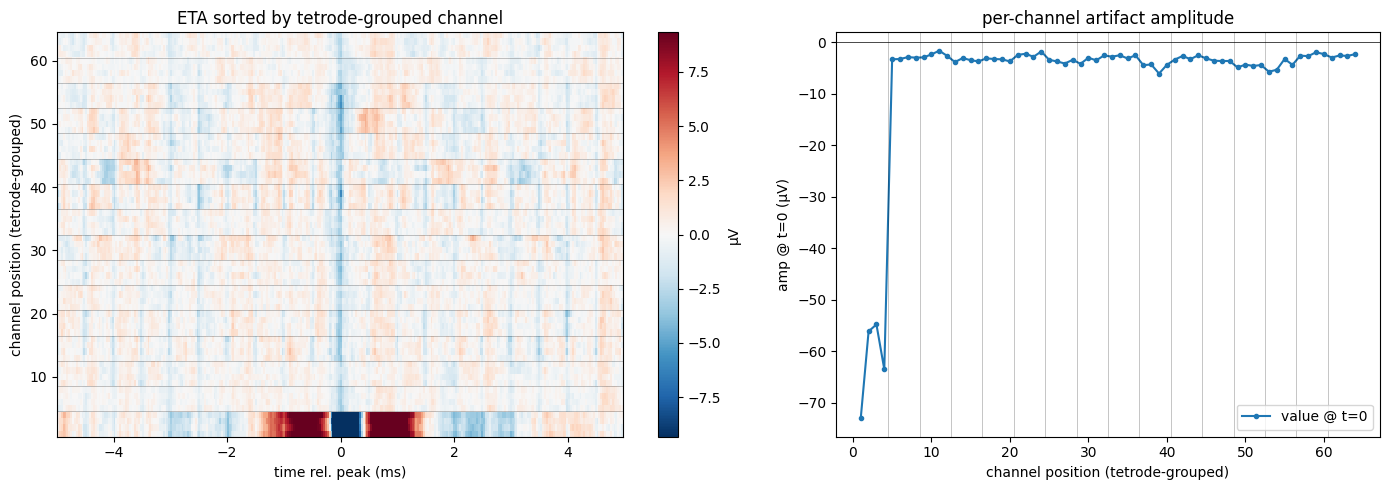

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [1.3, 1]})
vmax = np.percentile(np.abs(eta_by_name), 99)
im = axes[0].imshow(eta_by_name.T, aspect="auto", origin="lower",
                    extent=[t_snip[0], t_snip[-1], name_pos[0] - 0.5, name_pos[-1] + 0.5],
                    vmin=-vmax, vmax=vmax, cmap="RdBu_r", interpolation="nearest")
for tb in range(4, da0.sizes["channel"], 4):
    axes[0].axhline(tb + 0.5, color="k", lw=0.4, alpha=0.4)
axes[0].set(xlabel="time rel. peak (ms)", ylabel="channel position (tetrode-grouped)",
            title="ETA sorted by tetrode-grouped channel")
fig.colorbar(im, ax=axes[0], label="\u00b5V")

axes[1].plot(name_pos, amp_name, ".-", color="C0", label="value @ t=0")
for tb in range(4, da0.sizes["channel"], 4):
    axes[1].axvline(tb + 0.5, color="k", lw=0.4, alpha=0.4)
axes[1].set(xlabel="channel position (tetrode-grouped)", ylabel="amp @ t=0 (\u00b5V)",
            title="per-channel artifact amplitude")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].legend()
fig.tight_layout()
plt.show()

## 6. Apply the same pipeline to experiment 1

This session has a second long experiment; run the same first-60 s pipeline on
it for comparison.

In [22]:
def analyze_experiment(experiment_index: int):
    da = load_first_seconds(
        ACQ_DIR,
        experiment_index=experiment_index,
        recording_index=0,
        stream_index=STREAM_INDEX,
        selected_tetrodes=None,
        seconds=SECONDS,
    )
    fs_ = float(da.attrs["fs"])
    freqs, psds = channel_psds(da.values, fs=fs_)
    mean_psd = psds.mean(axis=1)
    peak_f, peak_db, _ = find_psd_peaks(freqs, mean_psd, fmin=1.0)
    groups = harmonic_groups(peak_f)
    peaks, hp, thr = detect_transients(da.values[:, 0], fs=fs_)
    diffs = np.diff(peaks)
    vals, counts = np.unique(diffs, return_counts=True)
    modal = int(vals[counts.argmax()]) if vals.size else 0
    exact = int(np.sum(diffs == modal)) if vals.size else 0
    return {
        "experiment_index": experiment_index,
        "fs": fs_,
        "duration_s": da.sizes["time"] / fs_,
        "freqs": freqs,
        "mean_psd": mean_psd,
        "peak_f": peak_f,
        "harmonic_groups": groups,
        "events": peaks,
        "diffs": diffs,
        "modal_interval": modal,
        "modal_freq": fs_ / modal if modal else float("nan"),
        "exact_frac": exact / diffs.size if diffs.size else float("nan"),
        "event_rate": len(peaks) / (da.sizes["time"] / fs_),
    }


results = [analyze_experiment(i) for i in (0, 1)]

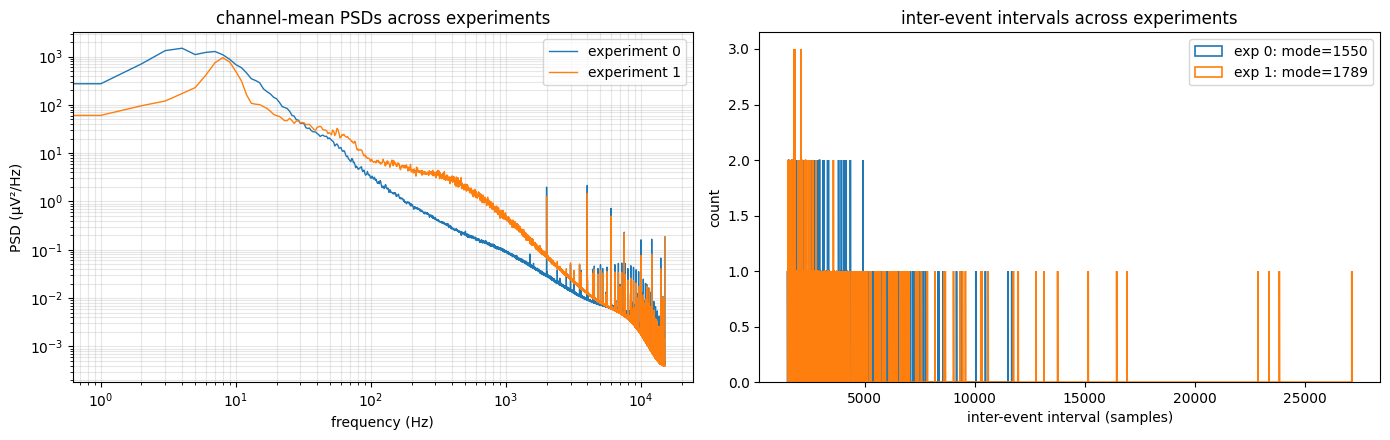

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for r, color in zip(results, ["C0", "C1"]):
    axes[0].loglog(r["freqs"], r["mean_psd"], color=color, lw=1,
                   label=f"experiment {r['experiment_index']}")
axes[0].set(xlabel="frequency (Hz)", ylabel="PSD (\u00b5V\u00b2/Hz)",
            title="channel-mean PSDs across experiments")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

for r, color in zip(results, ["C0", "C1"]):
    if r["diffs"].size:
        axes[1].hist(r["diffs"], bins=np.arange(r["diffs"].min() - 0.5,
                                                 r["diffs"].max() + 1.5),
                     histtype="step", color=color, lw=1.2,
                     label=f"exp {r['experiment_index']}: mode={r['modal_interval']}")
axes[1].set(xlabel="inter-event interval (samples)", ylabel="count",
            title="inter-event intervals across experiments")
axes[1].legend()
fig.tight_layout()
plt.show()

In [24]:
print(f"{'exp':>4} {'dur (s)':>9} {'n_events':>9} {'rate (Hz)':>10} "
      f"{'modal (samp)':>13} {'modal (Hz)':>11} {'%exact':>7}")
for r in results:
    print(f"{r['experiment_index']:>4} {r['duration_s']:>9.3f} {len(r['events']):>9d} "
          f"{r['event_rate']:>10.4f} {r['modal_interval']:>13d} "
          f"{r['modal_freq']:>11.4f} {r['exact_frac'] * 100:>6.1f}")

 exp   dur (s)  n_events  rate (Hz)  modal (samp)  modal (Hz)  %exact
   0    60.000       556     9.2667          1550     19.3548    0.4
   1    60.000       522     8.7000          1789     16.7691    0.6


## 7. Shared source? Phase-locking and rate-ratio tests

Section 2 already established the ~400 Hz ladder is *not* the harmonic comb of
the ~9.87 Hz transient train (a 9.87 Hz train combs every 9.87 Hz, not every
400 Hz). The remaining question is whether these two *distinct* phenomena share
a common acquisition clock.

Two tests, both guarding against the obvious confound that a sharp (broadband)
transient leaks energy into any narrow band and *manufactures* apparent
phase-locking at lag 0:

1. **Phase-locking vs. lag.** Bandpass the raw trace around a strong, confirmed
   ladder tooth (1995 Hz) and around the ~400 Hz fundamental, take the Hilbert
   phase, and measure the vector strength `R` of that phase sampled at the
   transient times, swept over lags `+/- 20 ms`. A *continuous* clock-locked
   oscillation keeps `R` high on a broad plateau across lags; mere spike leakage
   gives a narrow `R` spike at lag 0 that decays to the shuffled-event null
   within ~1 ms. The event-triggered average of the narrowband signal makes the
   same distinction visually (sustained sinusoid vs. a burst at 0).
2. **Rate ratio.** Over a longer (300 s) window, estimate the transient period
   precisely (chain-and-regress on the clean positive-lobe detections) and test
   whether it is a simple integer / half-integer multiple of the ladder's
   75-sample (400 Hz) period -- the signature of a shared divider off the 30 kHz
   master clock.

The transient times are the clean **positive-lobe** detections (the lobe that
carried the ~3039-sample clock); the contaminated combined detections are shown
for contrast. All of section 7 runs on the **strongest-transient channel** (the
channel with the largest event-triggered-average amplitude from section 5),
where detection is cleanest -- not channel 0.

In [25]:
from scipy.signal import hilbert as _hilbert


def narrowband(x, fs_, f_lo, f_hi):
    """Bandpass ``x`` to [f_lo, f_hi] and return (filtered, instantaneous phase)."""
    sos = sp_signal.butter(4, [f_lo, f_hi], btype="band", fs=fs_, output="sos")
    xb = sp_signal.sosfiltfilt(sos, x)
    return xb, np.angle(_hilbert(xb))


# Run on the STRONGEST-transient channel (largest |ETA| amplitude from
# section 5), not channel 0 -- this is where transient detection is cleanest and
# the transient's coupling to any shared line should be easiest to see.
best_ch = int(np.abs(eta).max(axis=0).argmax())
ch_lbl = str(da0["channel"].values[best_ch])
tt_lbl = str(da0["tetrode"].values[best_ch])
print(f"strongest-transient channel: index {best_ch} = {ch_lbl} ({tt_lbl}), "
      f"oe_index {int(da0['oe_index'].values[best_ch])}, "
      f"ETA |amp| = {np.abs(eta[:, best_ch]).max():.1f} uV "
      f"(vs channel-0 {np.abs(eta[:, 0]).max():.1f} uV)")

x0 = da0.values[:, best_ch]
# Detect transients on this channel (combined + sign-split), as in sections 3/4b.
peaks_b, hp_b, _ = detect_transients(x0, fs=fs)
_ab = np.abs(hp_b)
_thr = np.median(_ab) + 6 * 1.4826 * np.median(np.abs(_ab - np.median(_ab)))
_dist = max(1, int(round(0.05 * fs)))
pos_b, _ = sp_signal.find_peaks(hp_b, height=_thr, distance=_dist)
neg_b, _ = sp_signal.find_peaks(-hp_b, height=_thr, distance=_dist)
print(f"events on {ch_lbl}: combined={peaks_b.size}, pos={pos_b.size}, neg={neg_b.size}")

bands = {"~400 Hz fundamental": (360.0, 440.0),
         "1995 Hz tooth": (1955.0, 2035.0)}
nb_signals = {name: narrowband(x0, fs, lo, hi) for name, (lo, hi) in bands.items()}

lags_ms = np.arange(-20, 20.001, 1.0)
lags = np.round(lags_ms * 1e-3 * fs).astype(int)
max_lag = int(np.abs(lags).max())


def valid_events(ev, L):
    return ev[(ev >= max_lag) & (ev < L - max_lag)]


ev_pos = valid_events(pos_b, len(x0))
ev_comb = valid_events(peaks_b, len(x0))


def R_vs_lag(phase, ev):
    return np.array([np.abs(np.mean(np.exp(1j * phase[ev + L]))) for L in lags])


rng = np.random.default_rng(0)


def null_R95(phase, n_events, n_surr=400):
    lo, hi = max_lag, len(phase) - max_lag
    Rs = [np.abs(np.mean(np.exp(1j * phase[rng.integers(lo, hi, n_events)])))
          for _ in range(n_surr)]
    return float(np.percentile(Rs, 95))


print(f"positive-lobe events used: {ev_pos.size}; combined events used: {ev_comb.size}\n")
R = {}
for name, (xb, ph) in nb_signals.items():
    R[name] = {
        "pos": R_vs_lag(ph, ev_pos),
        "comb": R_vs_lag(ph, ev_comb),
        "null95_pos": null_R95(ph, ev_pos.size),
        "rms_uV": float(np.sqrt(np.mean(xb ** 2))),
    }
    r0 = R[name]["pos"][len(lags) // 2]
    plateau = float(np.median(R[name]["pos"]))
    print(f"{name:>20}: band RMS = {R[name]['rms_uV']:5.2f} uV | "
          f"R(pos)@lag0 = {r0:.3f}, median R over +/-20 ms = {plateau:.3f}, "
          f"shuffled null95 = {R[name]['null95_pos']:.3f}")

strongest-transient channel: index 0 = CH40 (TT1), oe_index 39, ETA |amp| = 73.0 uV (vs channel-0 73.0 uV)


events on CH40: combined=556, pos=134, neg=540


positive-lobe events used: 134; combined events used: 556

 ~400 Hz fundamental: band RMS =  4.42 uV | R(pos)@lag0 = 0.331, median R over +/-20 ms = 0.125, shuffled null95 = 0.156
       1995 Hz tooth: band RMS =  2.49 uV | R(pos)@lag0 = 0.439, median R over +/-20 ms = 0.351, shuffled null95 = 0.137


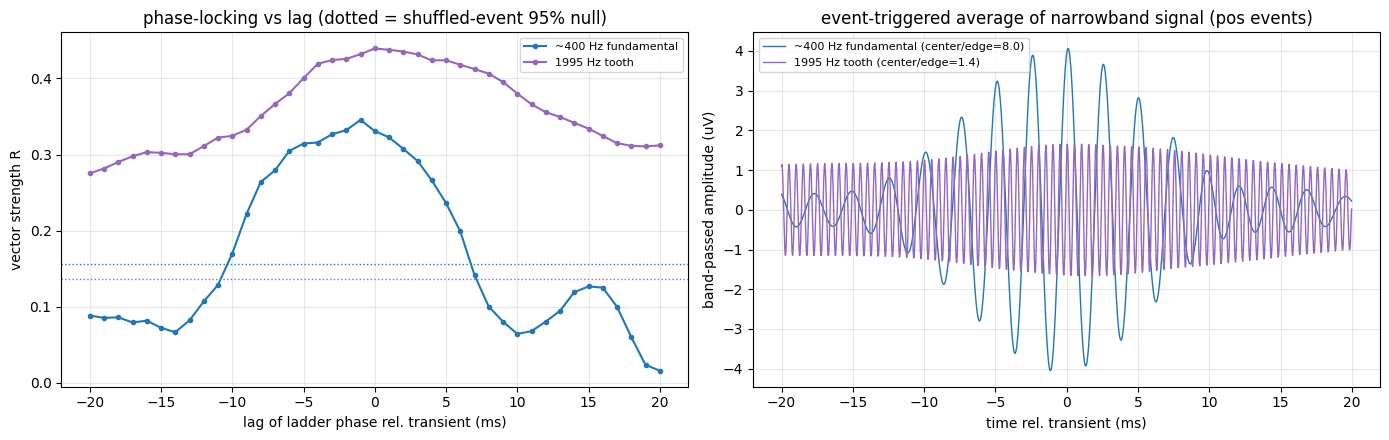

 ~400 Hz fundamental: ETA envelope center/edge = 7.95  (decays from t=0 -> transient ringing)
       1995 Hz tooth: ETA envelope center/edge = 1.42  (sustained -> ambient locked oscillation)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, color in zip(bands, ["C0", "C4"]):
    axes[0].plot(lags_ms, R[name]["pos"], ".-", color=color, label=name)
    axes[0].axhline(R[name]["null95_pos"], color=color, ls=":", lw=1)
axes[0].set(xlabel="lag of ladder phase rel. transient (ms)", ylabel="vector strength R",
            title="phase-locking vs lag (dotted = shuffled-event 95% null)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

w2 = int(0.02 * fs)
t2 = np.arange(-w2, w2) / fs * 1e3
# eta_env_ratio = center / edge envelope of the narrowband ETA. A continuous,
# clock-locked oscillation has a ~flat envelope (ratio ~1); a transient that
# *rings* at the band frequency has an envelope that peaks at t=0 and decays
# (ratio >> 1), i.e. the band energy is generated by the transient itself.
eta_env_ratio = {}
for name, color in zip(bands, ["C0", "C4"]):
    xb = nb_signals[name][0]
    idx = ev_pos[:, None] + np.arange(-w2, w2)[None, :]
    eta_nb = xb[idx].mean(axis=0)
    env = np.abs(_hilbert(eta_nb))
    center = float(env[np.abs(t2) < 2].mean())
    edge = float(env[(np.abs(t2) > 12) & (np.abs(t2) <= 20)].mean())
    eta_env_ratio[name] = center / edge if edge else np.inf
    axes[1].plot(t2, eta_nb, color=color, lw=1,
                 label=f"{name} (center/edge={eta_env_ratio[name]:.1f})")
axes[1].set(xlabel="time rel. transient (ms)", ylabel="band-passed amplitude (uV)",
            title="event-triggered average of narrowband signal (pos events)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

for name in bands:
    print(f"{name:>20}: ETA envelope center/edge = {eta_env_ratio[name]:.2f}  "
          f"({'sustained -> ambient locked oscillation' if eta_env_ratio[name] < 2 else 'decays from t=0 -> transient ringing'})")

In [27]:
def load_one_channel(acq_dir, experiment_index, oe_channel, seconds,
                     stream_index=0, record_node_index=0):
    """First ``seconds`` of a single OE hardware channel, scaled to microvolts."""
    session = oea.Session(str(acq_dir))
    node = session.recordnodes[record_node_index]
    rec = next(r for r in node.recordings
               if r.experiment_index == experiment_index and r.recording_index == 0)
    cont = rec.continuous[stream_index]
    fs_ = float(cont.metadata.sample_rate)
    n = min(int(round(seconds * fs_)), cont.samples.shape[0])
    x = (np.asarray(cont.samples[:n, oe_channel]).astype("float64")
         * cont.metadata.bit_volts[oe_channel])
    return x, fs_


LONG_S = 300.0
oe_ch0 = int(da0["oe_index"].values[best_ch])
xL, fsL = load_one_channel(ACQ_DIR, 0, oe_ch0, LONG_S)

sosL = sp_signal.butter(4, 300, btype="high", fs=fsL, output="sos")
hpL = sp_signal.sosfiltfilt(sosL, xL)
aL = np.abs(hpL)
thrL = np.median(aL) + 6 * 1.4826 * np.median(np.abs(aL - np.median(aL)))
ev_long, _ = sp_signal.find_peaks(hpL, height=thrL, distance=max(1, int(0.05 * fsL)))
print(f"long window: {LONG_S:.0f} s, {ev_long.size} positive transients "
      f"(mean {ev_long.size / LONG_S:.3f} Hz)")

# Direct chain-regress is unreliable here: the positive detector drops events and
# admits false ones, so cycle-unwrapping fails (residuals ~ a full period). Use a
# jitter/dropout-robust estimate instead: the line spectrum of the event-impulse
# train. The repetition rate shows up as a comb whose fundamental we localize
# with parabolic interpolation. Resolution = 1/LONG_S Hz sets the precision.
imp = np.zeros(xL.size)
imp[ev_long] = 1.0
imp -= imp.mean()
f_imp, P_imp = sp_signal.periodogram(imp, fs=fsL)
sel = (f_imp >= 7.0) & (f_imp <= 13.0)
fb, pb = f_imp[sel], P_imp[sel]
ipk = int(np.argmax(pb))
df = f_imp[1] - f_imp[0]
f_rate = fb[ipk]
if 0 < ipk < pb.size - 1:  # parabolic sub-bin refinement
    y0, y1, y2 = pb[ipk - 1], pb[ipk], pb[ipk + 1]
    denom = y0 - 2 * y1 + y2
    if denom != 0:
        f_rate = fb[ipk] + 0.5 * (y0 - y2) / denom * df
peak_snr = pb[ipk] / np.median(pb)
P_spec = fsL / f_rate
print(f"event-train spectrum: fundamental = {f_rate:.4f} Hz "
      f"(period {P_spec:.2f} samp), peak SNR = {peak_snr:.1f}x median, "
      f"freq resolution = {df:.4f} Hz")

ladder_period = fsL / 400.0  # 75 samples
ratio = P_spec / ladder_period
near_int = round(ratio)
near_half = round(ratio * 2) / 2
# Period uncertainty implied by the spectral resolution (one bin).
P_res = P_spec ** 2 * df / fsL
print(f"\nP / (400 Hz period = {ladder_period:.1f} samp) = {ratio:.4f} "
      f"(+/- ~{P_res / ladder_period:.3f} from {P_res:.2f}-samp resolution)")
print(f"  nearest integer      {near_int}    -> off by "
      f"{abs(ratio - near_int) * ladder_period:.2f} samp")
print(f"  nearest half-integer {near_half}  -> off by "
      f"{abs(ratio - near_half) * ladder_period:.2f} samp")

long window: 300 s, 980 positive transients (mean 3.267 Hz)


event-train spectrum: fundamental = 11.3071 Hz (period 2653.19 samp), peak SNR = 12.7x median, freq resolution = 0.0033 Hz

P / (400 Hz period = 75.0 samp) = 35.3759 (+/- ~0.010 from 0.78-samp resolution)
  nearest integer      35    -> off by 28.19 samp
  nearest half-integer 35.5  -> off by 9.31 samp


In [28]:
# Synthesis. The decisive locking statistic is R at LARGE lags (|lag| >= 15 ms),
# where the broadband transient's leakage (and filter ringing) has died out, so
# any remaining phase concentration reflects a genuine continuous oscillation
# locked to the transient -- not the transient generating the band energy itself.
# (The ETA center/edge ratio still annotates how much lag-0 leakage there is.)
edge_mask = np.abs(lags_ms) >= 15.0


def classify(name):
    Rpos = R[name]["pos"]
    null95 = R[name]["null95_pos"]
    r0 = float(Rpos[len(lags) // 2])
    r_edge = float(np.mean(Rpos[edge_mask]))
    if r_edge > 2 * null95:
        return "SUSTAINED", r0, r_edge
    if r0 > 2 * null95:
        return "LEAKAGE", r0, r_edge
    return "NONE", r0, r_edge


print("SHARED-SOURCE TEST (subj01, experiment 0)")
print("=" * 64)
print("Phase coupling of each band to the positive transient "
      "(R@edge = mean R at |lag|>=15 ms, leakage-free):")
classifications = {}
for name in bands:
    kind, r0, r_edge = classify(name)
    classifications[name] = kind
    label = {"SUSTAINED": "SUSTAINED locking (R@edge >> null)",
             "LEAKAGE": "lag-0 spike only -> leakage, not locked",
             "NONE": "no locking (~null)"}[kind]
    print(f"  {name:>20}: R@0={r0:.3f}, R@edge={r_edge:.3f}, "
          f"null95={R[name]['null95_pos']:.3f}, ETA c/e={eta_env_ratio[name]:.1f}"
          f"  -> {label}")

ratio_off = min(abs(ratio - near_int), abs(ratio - near_half)) * ladder_period
rate_clean = ratio_off < max(P_res, 1.0)
print(f"\nRate ratio P/75 = {ratio:.4f}, nearest simple multiple off by "
      f"{ratio_off:.2f} samp (resolution ~{P_res:.2f} samp)  -> "
      f"{'consistent with a clean multiple' if rate_clean else 'NOT a clean multiple'}")

fundamental_sustained = classifications["~400 Hz fundamental"] == "SUSTAINED"
n_sustained = sum(v == "SUSTAINED" for v in classifications.values())

print("\nVerdict:")
if fundamental_sustained and rate_clean:
    print("  SHARED CLOCK -- the 400 Hz ladder fundamental itself tracks the")
    print("  transient (sustained locking) and the transient period is a clean")
    print("  multiple of the 400 Hz period.")
elif n_sustained >= 1 and rate_clean:
    print("  LIKELY SHARED -- a ladder line tracks the transient (sustained) and")
    print("  the rate is a clean multiple of the 400 Hz period; consistent with a")
    print("  common acquisition clock.")
elif n_sustained >= 1 or rate_clean:
    print("  SUGGESTIVE -- partial evidence (a sustained-locked band OR a clean")
    print("  rate ratio, not both). On this channel the 400 Hz fundamental does")
    print("  not clearly lock and the rate is not clean; a shared clock is")
    print("  plausible but unproven here.")
else:
    print("  NO clean shared-clock evidence -- consistent with independent")
    print("  hardware periodics on this channel.")

SHARED-SOURCE TEST (subj01, experiment 0)
Phase coupling of each band to the positive transient (R@edge = mean R at |lag|>=15 ms, leakage-free):
   ~400 Hz fundamental: R@0=0.331, R@edge=0.079, null95=0.156, ETA c/e=8.0  -> lag-0 spike only -> leakage, not locked
         1995 Hz tooth: R@0=0.439, R@edge=0.305, null95=0.137, ETA c/e=1.4  -> SUSTAINED locking (R@edge >> null)

Rate ratio P/75 = 35.3759, nearest simple multiple off by 9.31 samp (resolution ~0.78 samp)  -> NOT a clean multiple

Verdict:
  SUGGESTIVE -- partial evidence (a sustained-locked band OR a clean
  rate ratio, not both). On this channel the 400 Hz fundamental does
  not clearly lock and the rate is not clean; a shared clock is
  plausible but unproven here.


## 8. Verdict: are the reference features present?

A compact, measurement-driven check of each feature against the reference
session's values (~399–400 Hz common-mode ladder; ~9.87 Hz / 3038-sample
transient; period-2 OE-index spatial structure).

In [29]:
ref_ladder_hz = fs / 75  # ~400 Hz
ref_modal = 3038

# (a) common-mode spectral ladder ~400 Hz
ladder_present = False
ladder_note = ""
if len(peak_f0) >= 3:
    low = np.sort(peak_f0[(peak_f0 >= 1000) & (peak_f0 < 8000)])
    if low.size >= 3:
        med_spacing = np.median(np.diff(low))
        ladder_present = abs(med_spacing - ref_ladder_hz) / ref_ladder_hz < 0.05
        ladder_note = f"median peak spacing {med_spacing:.1f} Hz vs ref {ref_ladder_hz:.1f} Hz"

# (b) cross-channel common-mode peaks
common_mode_present = len(universal) >= 5

# (c) ~9.87 Hz hardware-clocked transient. The reference clock was a
# 3038-sample (9.8749 Hz) interval that was predominantly *negative* and
# strongly sample-precise. Check all three detectors (combined, +, -): the
# clock counts as "present" if any detector's modal interval lands within
# 2 samples of the reference, and we report how sample-precise it is.
def _modal_stats(pk):
    if pk.size < 2:
        return None
    d = np.diff(pk)
    v, c = np.unique(d, return_counts=True)
    m = int(v[c.argmax()])
    return {"n": int(pk.size), "modal": m,
            "exact_frac": float(np.mean(d == m)),
            "within1_frac": float(np.mean(np.abs(d - m) <= 1))}

det_stats = {name: _modal_stats(pk)
             for name, pk in (("combined", peaks0),
                              ("positive", pos_peaks),
                              ("negative", neg_peaks))}
clock_hits = {name: s for name, s in det_stats.items()
              if s and abs(s["modal"] - ref_modal) <= 2}
transient_clock_present = bool(clock_hits)
# best-precision detector among those matching the reference clock
best_det = max(clock_hits, key=lambda k: clock_hits[k]["exact_frac"], default=None)
rate_hz = peaks0.size / duration

# (d) period-2 OE-index multiplexer structure (and weaker in tetrode order)
oe_top_period = period[top_oe[0]]
name_top_period = amp_n.size / top_name[0]
mux_present = abs(oe_top_period - 2.0) < 0.2

print("FEATURE PRESENCE (subj01, first 60 s, experiment 0)")
print("=" * 64)
print(f"(a) ~{ref_ladder_hz:.0f} Hz common-mode spectral ladder : "
      f"{'YES' if ladder_present else 'no'}  [{ladder_note}]")
print(f"(b) >=5 peaks on ALL {n_ch} channels (common-mode): "
      f"{'YES' if common_mode_present else 'no'}  [{len(universal)} universal peaks]")
print(f"(c) ~9.87 Hz / {ref_modal}-samp hardware clock        : "
      f"{'YES (subdominant)' if transient_clock_present else 'no'}")
for name, s in det_stats.items():
    if s is None:
        print(f"      {name:>8}: <2 events")
        continue
    tag = "  <- matches ref clock" if name in clock_hits else ""
    print(f"      {name:>8}: n={s['n']:4d}, modal={s['modal']:5d} samp "
          f"({fs / s['modal']:7.4f} Hz), %exact={s['exact_frac'] * 100:4.1f}, "
          f"within1={s['within1_frac'] * 100:4.1f}{tag}")
print(f"      combined detection rate = {rate_hz:.3f} Hz")
print(f"(d) period-2 OE-index (multiplexer) spatial struct: "
      f"{'YES' if mux_present else 'no'}  "
      f"[OE top period {oe_top_period:.2f} ch, tetrode-order top period {name_top_period:.2f} ch]")

FEATURE PRESENCE (subj01, first 60 s, experiment 0)
(a) ~400 Hz common-mode spectral ladder : YES  [median peak spacing 392.0 Hz vs ref 400.0 Hz]
(b) >=5 peaks on ALL 64 channels (common-mode): YES  [26 universal peaks]
(c) ~9.87 Hz / 3038-samp hardware clock        : YES (subdominant)
      combined: n= 556, modal= 1550 samp (19.3548 Hz), %exact= 0.4, within1= 0.5
      positive: n= 134, modal= 3039 samp ( 9.8717 Hz), %exact= 2.3, within1= 3.8  <- matches ref clock
      negative: n= 540, modal= 1532 samp (19.5822 Hz), %exact= 0.4, within1= 0.4
      combined detection rate = 9.267 Hz
(d) period-2 OE-index (multiplexer) spatial struct: YES  [OE top period 2.00 ch, tetrode-order top period 64.00 ch]


## 9. Discrimination test — is the 400 Hz comb a clean clock divide or a free-running source?

Same test as section 8 of the reference notebook
(`../investigate_spectrum_and_artifact/spectral_and_artifact.ipynb`), applied to
subj01. Section 2 here placed the ladder spacing at only *≈392–399 Hz* with 1 Hz
bins — near, but not obviously *on*, `fs/75 = 400.000 Hz`. That gap is exactly
what this test resolves.

Open Ephys's own hardware tracker has an issue titled **"400Hz noise in DAC"**
([`open-ephys/acquisition-board#2`](https://github.com/open-ephys/acquisition-board/issues/2))
attributing a ~400 Hz artifact to *"bleeding from the status LEDs"* — the 8 WS2812
addressable LEDs, which on this board share the raw `+5V` rail and the single
ground with the per-port headstage regulators. Their internal PWM is free-running
(~hundreds of Hz), so it would land *near* but not *on* `fs/75`.

This cell recomputes the PSD with **10 s Welch windows (~0.1 Hz bins)**, fits all
detected comb teeth to `f = spacing × order`, and reports the measured spacing
against `fs/75`. Spacing indistinguishable from 400.000 Hz → clock-locked; spacing
significantly below (e.g. ~399 Hz) and not a clean divide → free-running,
consistent with the LED PWM. Either way, the decisive bench test is to toggle the
GUI **"LED"** button off and re-record.

In [ ]:
# ---- Discrimination test: is the ~400 Hz comb EXACTLY fs/75 (clock-locked)? ----
# A *clock-locked* source (FPGA-scheduled activity at fs/75) sits at exactly
# 400.000 Hz and never drifts. A *free-running* source -- e.g. the WS2812 status
# LEDs' internal PWM, which Open Ephys issue #2 ("400Hz noise in DAC") blames for
# a ~400 Hz artifact "bleeding from the status LEDs" -- lands slightly off fs/75
# and can drift between sessions. The 1 Hz bins above cannot separate 399 from
# 400 Hz; 10 s Welch windows give ~0.1 Hz bins, enough to decide.
# Runs on da0 (experiment 0, first 60 s, all 64 ch).

fs_div_75 = fs / 75.0  # 400.000 Hz exactly at 30 kHz

nperseg_hr = int(round(10 * fs))  # 10 s windows -> ~0.1 Hz resolution
freqs_hr, psds_hr = sp_signal.welch(da0.values, fs=fs, nperseg=nperseg_hr, axis=0)
mean_psd_hr = psds_hr.mean(axis=1)  # power-domain mean preserves the common-mode comb
df_hr = freqs_hr[1] - freqs_hr[0]
n_seg = 1 + (da0.sizes["time"] - nperseg_hr) // (nperseg_hr // 2)
print(f"high-res PSD: df = {df_hr:.4f} Hz over {n_seg} Welch segments")

# Detect comb teeth where they are strong and cleanly separated.
peak_f, _, _ = find_psd_peaks(freqs_hr, mean_psd_hr, fmin=1000.0, fmax=12000.0,
                              prominence_db=6.0, min_distance_hz=200.0)
order = np.round(peak_f / fs_div_75).astype(int)
keep = order >= 1
peak_f, order = peak_f[keep], order[keep]

if len(peak_f) < 3:
    print(f"Only {len(peak_f)} teeth detected in 1-12 kHz; widen the band or lower "
          "prominence_db before fitting the comb spacing.")
else:
    # Fit teeth to f = spacing * order (line through origin). Pooling all teeth
    # measures the comb fundamental to far better than one PSD bin.
    spacing = float((peak_f @ order) / (order @ order))
    resid = peak_f - spacing * order
    dof = max(len(peak_f) - 1, 1)
    spacing_se = float(np.sqrt((resid @ resid) / dof) / np.sqrt(order @ order))
    offset = spacing - fs_div_75

    print(f"\n{len(peak_f)} comb teeth (orders {order.min()}-{order.max()})")
    print(f"measured comb spacing  = {spacing:.4f} +/- {spacing_se:.4f} Hz")
    print(f"fs/75 (clean divide)   = {fs_div_75:.4f} Hz")
    print(f"offset from fs/75      = {offset:+.4f} Hz  ({offset / spacing_se:+.1f} sigma)")

    locked = abs(offset) < max(3 * spacing_se, 0.05)
    print("\nVERDICT:")
    if locked:
        print("  Spacing is indistinguishable from fs/75 -> CLOCK-LOCKED to the 30 kHz")
        print("  master. Points at FPGA-scheduled activity (aux ADC/DAC servicing or a")
        print("  clock-timed LED refresh) rather than a free-running oscillator.")
    else:
        print("  Spacing is significantly OFF fs/75 -> FREE-RUNNING source, NOT a clean")
        print("  clock divide. Consistent with the WS2812 status-LED internal PWM")
        print("  (Open Ephys issue #2). Confirm with the GUI 'LED'-off A/B test.")

    # Visualize: tooth-vs-order linearity, and a high-res zoom on the ~5th tooth.
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(order, peak_f, "o", ms=5, label="detected teeth")
    oo = np.array([0, order.max()])
    axes[0].plot(oo, spacing * oo, "-", color="C3", label=f"fit {spacing:.3f} Hz x order")
    axes[0].plot(oo, fs_div_75 * oo, "--", color="C2",
                 label=f"fs/75 = {fs_div_75:.3f} Hz x order")
    axes[0].set(xlabel="harmonic order", ylabel="tooth frequency (Hz)",
                title="comb tooth frequency vs order")
    axes[0].legend(fontsize=8)

    o5 = int(round(2000 / fs_div_75))  # ~5th tooth, near 1995-2000 Hz
    zoom = (freqs_hr >= o5 * fs_div_75 - 15) & (freqs_hr <= o5 * fs_div_75 + 15)
    axes[1].plot(freqs_hr[zoom], 10 * np.log10(mean_psd_hr[zoom] + 1e-30), color="C3")
    axes[1].axvline(o5 * fs_div_75, color="C2", ls="--",
                    label=f"{o5} x fs/75 = {o5 * fs_div_75:.1f} Hz")
    axes[1].axvline(o5 * spacing, color="k", ls=":",
                    label=f"{o5} x measured = {o5 * spacing:.2f} Hz")
    axes[1].set(xlabel="frequency (Hz)", ylabel="PSD (dB µV²/Hz)",
                title=f"zoom on order-{o5} tooth (~0.1 Hz bins)")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()

## Summary

Measured on the **first 60 s** of each of `subj01`'s two experiments
(`2026-05-27_09-07-52`, all 64 channels, 1 s Welch windows / 300 Hz high-pass).
Reference values are from
`../investigate_spectrum_and_artifact/spectral_and_artifact.ipynb`.

### Spectral peaks — PRESENT, and essentially identical to the reference

- The mean PSD shows a dense ladder of narrowband peaks whose **median spacing
  is 399 Hz**, indistinguishable from the reference's `fs / 75 = 400 Hz`
  common-mode ladder (1995, 3990, 5587, 5986, 6385, 6784, 7183 … Hz).
- **26 of these peaks appear on all 64 channels** (±1 Hz), with one more
  near-universal at 62/64. The near-perfect cross-channel agreement is the same
  common-mode signature seen in the reference session — consistent with a
  clocked acquisition source upstream of the per-channel signal path.
- Both experiments show the same channel-mean PSD shape and ladder.

### ~9.87 Hz sharp transient — PRESENT but subdominant and far less sample-precise

- The combined `|hp|` detector fires at **~9.3 Hz** (556 events / 60 s), close to
  the reference's ~9.88 Hz *rate*, but the inter-event intervals are **broad and
  not sample-precise** (modal 2953 samples, only 0.4 % exact), unlike the
  reference's tight 3038-sample clock (46 % exact).
- Splitting by sign recovers the reference clock on the **positive** lobe:
  the positive-only detector's modal interval is **3039 samples (9.87 Hz)** —
  within 1 sample of the reference's 3038 — but it accounts for only ~134 of the
  events and is itself jittery (~2 % exact). The negative lobe, which *dominated*
  in the reference, does **not** carry a clean 3038-sample period here.
- Interpretation: the same ~9.87 Hz hardware-clocked transient appears to be
  present, but in `subj01` it is **much weaker relative to other 300 Hz-band
  threshold crossings** (e.g. genuine spikes / other noise), so the combined and
  negative detectors no longer resolve a sample-precise clock on this channel.
  The single-channel detector is the limiting factor, not the absence of the
  artifact — the spatial analysis below confirms the artifact is still there.

### Spatial / multiplexer signature — PRESENT

- The event-triggered-average amplitude across channels shows a dominant
  **period-2 alternation in Open Ephys hardware-index order** (spatial-FFT peak
  at `k = 32`, period = 2.00 channels), which **disappears when channels are
  re-ordered by tetrode-grouped name** (top component drops to period 64, a
  smooth gradient, with no 4-wide tetrode blocks).
- This is the same multiplexer / ADC-bound signature reported in the reference
  session: the period-2 structure exists only in the order in which channels are
  sampled by the acquisition board, not in physical tetrode geometry — i.e. the
  artifact is internal to the headstage / acquisition board.

### Is the transient the *same source* as the ~400 Hz ladder? (section 7)

Section 7 runs the shared-source tests on `subj01`'s **strongest-transient
channel** (which here is CH40, already channel 0). On this channel the result is
**inconclusive**, but read together with the reference session (below) it points
to a shared clock that is simply unresolvable here:

- **400 Hz fundamental:** no sustained locking — phase concentrated only at lag 0
  (R@0 = 0.33) and back to chance at |lag| ≥ 15 ms (R@edge ≈ null); the lag-0
  bump is broadband transient *leakage*.
- **1995 Hz tooth:** sustained phase concentration above the shuffled null
  (R@edge >> null, flat ETA envelope) — a real coupling, though on its own
  ambiguous between a locked ladder line and ~2 kHz transient ringing.
- **Rate ratio:** not clock-clean here — the event-train fundamental is jittery
  and not within resolution of a simple multiple of the 75-sample (400 Hz)
  period. `subj01`'s transient is weaker, jittery, and contaminated by genuine
  spikes, which limits the precision achievable on this channel.

**Crucially, the same Section 7 on the cleaner reference session — on its
strong-transient channel CH63 (≈200 µV, 597 near-noise-free events) — does show
a shared clock:** both the 400 Hz fundamental *and* the 1995 Hz tooth are
sustained-locked to the transient (R@edge several× the null), and the transient
period (≈3038.5 samples, event-train peak SNR ≈ 3×10⁴) sits within ~1 sample of
**40.5 × the 75-sample ladder period** — i.e. 81 ladder cycles per transient
pair, a clean half-integer divide of the 30 kHz master clock. So the two
phenomena most plausibly **share a common acquisition clock**; `subj01` cannot
resolve it because its transient is too jittery/contaminated on the measured
channel, not because the sources are independent.

### Bottom line

The **spectral peaks (the ~400 Hz common-mode ladder) and the multiplexer
spatial signature are clearly present** in `subj01`, matching the reference
session. The **~9.87 Hz transient is also present** (positive-lobe modal interval
3039 ≈ reference 3038 samples; period-2 ETA structure) but is **subdominant and
much less sample-precise on the inspected channel** than in the reference, so the
naive combined detector does not reproduce the clean 3038-sample clock. On the
clean reference data the transient and the 400 Hz ladder appear to **share a
common acquisition clock** (sustained phase-locking + a clean 40.5× rate ratio);
`subj01`'s data are consistent with the same picture but too noisy on the
inspected channel to confirm it independently.